# 01. Data Inspection Report - CIC-IDS2017 Dataset

This notebook performs a comprehensive, real exploratory data inspection on the raw CIC-IDS2017 cybersecurity dataset located in `data/raw/cybersecurity/`.

**Strict Inspection Rules Enforced:**
- Strictly read-only exploration (no raw CSV files modified).
- No data preprocessing, row dropping, or model training.
- Dynamic schema discovery and quality checks.

## 1. Import Libraries & Configuration

In [1]:
import os
import glob
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset Discovery

Locate all raw CSV files under `data/raw/cybersecurity/` recursively and record file statistics including size, row count, and column count.

In [2]:
# Raw data directory path
DATA_DIR = os.path.join("..", "data", "raw", "cybersecurity")
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join("data", "raw", "cybersecurity")

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True))

discovery_records = []
total_raw_rows = 0
total_raw_bytes = 0

for fpath in csv_files:
    fname = os.path.basename(fpath)
    file_bytes = os.path.getsize(fpath)
    file_mb = file_bytes / (1024 * 1024)
    total_raw_bytes += file_bytes
    
    # Fast line count for exact raw row count
    with open(fpath, 'rb') as fp:
        line_count = sum(1 for _ in fp) - 1  # subtract header row
    total_raw_rows += line_count
    
    # Read header row to count columns
    df_hdr = pd.read_csv(fpath, nrows=1)
    
    discovery_records.append({
        'Filename': fname,
        'Size (MB)': round(file_mb, 2),
        'Rows': line_count,
        'Columns': len(df_hdr.columns)
    })

df_discovery = pd.DataFrame(discovery_records)
display(df_discovery)
print(f"Total CSV Files Discovered: {len(csv_files)}")
print(f"Total Dataset File Size: {total_raw_bytes / (1024 * 1024):.2f} MB")
print(f"Total Combined Raw Rows: {total_raw_rows:,}")

,Filename,Size (MB),Rows,Columns
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,73.5500,225745,79
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,73.3400,286467,79
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,55.6200,191033,79
3,Monday-WorkingHours.pcap_ISCX.csv,168.7300,529918,79
4,Thursday-WorkingHours-Afternoon-Infilteration....,79.2500,288602,79
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,49.6100,170366,79
6,Tuesday-WorkingHours.pcap_ISCX.csv,128.8200,445909,79
7,Wednesday-workingHours.pcap_ISCX.csv,214.7400,692703,79


Total CSV Files Discovered: 8
Total Dataset File Size: 843.66 MB
Total Combined Raw Rows: 2,830,743


## 3. Dataset Loading

Load all identified CSV files into a unified pandas DataFrame cleanly. Avoid unnecessary memory duplicates by reading in sequence and combining into `df`. Column names are stripped of whitespace.

In [3]:
loaded_dfs = []
for fpath in csv_files:
    fname = os.path.basename(fpath)
    print(f"Loading '{fname}'...")
    # Handle UTF-8 encoding safely with replacement for special characters
    chunk = pd.read_csv(fpath, encoding='utf-8', encoding_errors='replace')
    # Strip whitespace from column headers
    chunk.columns = chunk.columns.str.strip()
    loaded_dfs.append(chunk)

df = pd.concat(loaded_dfs, ignore_index=True)
del loaded_dfs  # Free memory list

print(f"\nUnified Dataset Loaded Successfully!")
print(f"Total Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
display(df.head(5))

Loading 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'...


Loading 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'...


Loading 'Friday-WorkingHours-Morning.pcap_ISCX.csv'...


Loading 'Monday-WorkingHours.pcap_ISCX.csv'...


Loading 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'...


Loading 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'...


Loading 'Tuesday-WorkingHours.pcap_ISCX.csv'...


Loading 'Wednesday-workingHours.pcap_ISCX.csv'...



Unified Dataset Loaded Successfully!
Total Shape: 2,830,743 rows x 79 columns
Memory Usage: 1833.87 MB


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,666666.6667,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,110091.7431,18348.6238,109.0000,0.0000,109,109,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,9174.3119,9174.3119,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,230769.2308,38461.5385,52.0000,0.0000,52,52,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,19230.7692,19230.7692,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,352941.1765,58823.5294,34.0000,0.0000,34,34,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,29411.7647,29411.7647,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,666666.6667,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN


## 4. Dataset Structure & Schema

Inspect overall dataset shape, full column names list, data types summary, and `df.info()`.

In [4]:
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns\n")

print("--- Column List ---")
for idx, col in enumerate(df.columns, 1):
    print(f"{idx:02d}. {col}")

print("\n--- Data Types Summary ---")
dtype_summary = df.dtypes.value_counts().reset_index()
dtype_summary.columns = ['Data Type', 'Count']
display(dtype_summary)

print("\n--- DataFrame Info Output ---")
buffer = io.StringIO()
df.info(verbose=False, buf=buffer)
print(buffer.getvalue())

Dataset Shape: 2,830,743 rows, 79 columns

--- Column List ---
01. Destination Port
02. Flow Duration
03. Total Fwd Packets
04. Total Backward Packets
05. Total Length of Fwd Packets
06. Total Length of Bwd Packets
07. Fwd Packet Length Max
08. Fwd Packet Length Min
09. Fwd Packet Length Mean
10. Fwd Packet Length Std
11. Bwd Packet Length Max
12. Bwd Packet Length Min
13. Bwd Packet Length Mean
14. Bwd Packet Length Std
15. Flow Bytes/s
16. Flow Packets/s
17. Flow IAT Mean
18. Flow IAT Std
19. Flow IAT Max
20. Flow IAT Min
21. Fwd IAT Total
22. Fwd IAT Mean
23. Fwd IAT Std
24. Fwd IAT Max
25. Fwd IAT Min
26. Bwd IAT Total
27. Bwd IAT Mean
28. Bwd IAT Std
29. Bwd IAT Max
30. Bwd IAT Min
31. Fwd PSH Flags
32. Bwd PSH Flags
33. Fwd URG Flags
34. Bwd URG Flags
35. Fwd Header Length
36. Bwd Header Length
37. Fwd Packets/s
38. Bwd Packets/s
39. Min Packet Length
40. Max Packet Length
41. Packet Length Mean
42. Packet Length Std
43. Packet Length Variance
44. FIN Flag Count
45. SYN Flag Coun

,Data Type,Count
0,int64,54
1,float64,24
2,str,1



--- DataFrame Info Output ---
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Columns: 79 entries, Destination Port to Label
dtypes: float64(24), int64(54), str(1)
memory usage: 1.7 GB



## 5. Missing Values Analysis

Calculate missing value counts and missing percentages for every column. Display only columns that contain missing values.

In [5]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': null_counts.index,
    'Missing Count': null_counts.values,
    'Missing Percentage (%)': null_pct.values
})

# Filter only columns with missing values (> 0)
missing_only = missing_df[missing_df['Missing Count'] > 0].reset_index(drop=True)

if len(missing_only) > 0:
    print(f"Found {len(missing_only)} column(s) with missing values:")
    display(missing_only)
else:
    print("No missing values found across all columns in the dataset.")

Found 1 column(s) with missing values:


,Column,Missing Count,Missing Percentage (%)
0,Flow Bytes/s,1358,0.0480


## 6. Duplicate Rows Analysis

Calculate the number of identical duplicate rows across all features and compute the duplicate percentage.
*Note: Duplicate rows are analyzed but strictly preserved.*

In [6]:
total_rows = len(df)
duplicate_count = df.duplicated().sum()
duplicate_pct = (duplicate_count / total_rows) * 100

dup_summary = pd.DataFrame({
    'Total Rows': [total_rows],
    'Duplicate Rows': [duplicate_count],
    'Duplicate Percentage (%)': [round(duplicate_pct, 4)]
})

display(dup_summary)
print(f"Duplicate Analysis Summary: {duplicate_count:,} duplicate rows detected ({duplicate_pct:.2f}% of dataset).")

,Total Rows,Duplicate Rows,Duplicate Percentage (%)
0,2830743,308381,10.8940


Duplicate Analysis Summary: 308,381 duplicate rows detected (10.89% of dataset).


## 7. Numerical Statistics

Generate descriptive statistics (mean, std, min, 25%, 50%, 75%, max) for all numerical features in the dataset.

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns
num_stats = df[num_cols].describe().T
num_stats['count'] = num_stats['count'].astype(int)

print(f"Descriptive Statistics for {len(num_cols)} Numerical Features:")
display(num_stats)

C:\Users\kpate\OneDrive\Documents\AegisNet\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\kpate\OneDrive\Documents\AegisNet\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Descriptive Statistics for 78 Numerical Features:


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743,8071.4825,18283.6322,0.0000,53.0000,80.0000,443.0000,65535.0000
Flow Duration,2830743,14785663.9295,33653744.0859,-13.0000,155.0000,31316.0000,3204828.5000,119999998.0000
Total Fwd Packets,2830743,9.3612,749.6728,1.0000,2.0000,2.0000,5.0000,219759.0000
Total Backward Packets,2830743,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000
Total Length of Fwd Packets,2830743,549.3024,9993.5892,0.0000,12.0000,62.0000,187.0000,12900000.0000
Total Length of Bwd Packets,2830743,16162.6425,2263088.0517,0.0000,0.0000,123.0000,482.0000,655453030.0000
Fwd Packet Length Max,2830743,207.5999,717.1848,0.0000,6.0000,37.0000,81.0000,24820.0000
Fwd Packet Length Min,2830743,18.7137,60.3393,0.0000,0.0000,2.0000,36.0000,2325.0000
Fwd Packet Length Mean,2830743,58.2019,186.0912,0.0000,6.0000,34.0000,50.0000,5940.8571
Fwd Packet Length Std,2830743,68.9101,281.1871,0.0000,0.0000,0.0000,26.1630,7125.5968


## 8. Categorical Analysis

Identify object/string columns, inspect unique value counts, and analyze value distributions.

In [8]:
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print(f"Identified Categorical/Object Columns ({len(cat_cols)}): {cat_cols}\n")

for col in cat_cols:
    n_unique = df[col].nunique(dropna=False)
    print(f"Column: '{col}' | Unique Values: {n_unique}")
    val_counts = df[col].value_counts(dropna=False).reset_index()
    val_counts.columns = [col, 'Count']
    val_counts['Percentage (%)'] = (val_counts['Count'] / len(df)) * 100
    display(val_counts)

Identified Categorical/Object Columns (1): ['Label']

Column: 'Label' | Unique Values: 15


,Label,Count,Percentage (%)
0,BENIGN,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695


## 9. Label Analysis

Identify the target label column (`Label`), list all unique attack/traffic classes with exact row counts and percentages, and display a distribution bar chart.

In [9]:
label_col = 'Label' if 'Label' in df.columns else [c for c in df.columns if 'label' in c.lower()][0]
print(f"Detected Target Label Column: '{label_col}'\n")

label_counts = df[label_col].value_counts(dropna=False)
label_pcts = (label_counts / len(df)) * 100

label_report = pd.DataFrame({
    'Class Label': label_counts.index,
    'Count': label_counts.values,
    'Percentage (%)': label_pcts.values
})

display(label_report)

Detected Target Label Column: 'Label'



,Class Label,Count,Percentage (%)
0,BENIGN,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695


C:\Users\kpate\AppData\Local\Temp\ipykernel_7340\3940908136.py:25: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\kpate\OneDrive\Documents\AegisNet\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


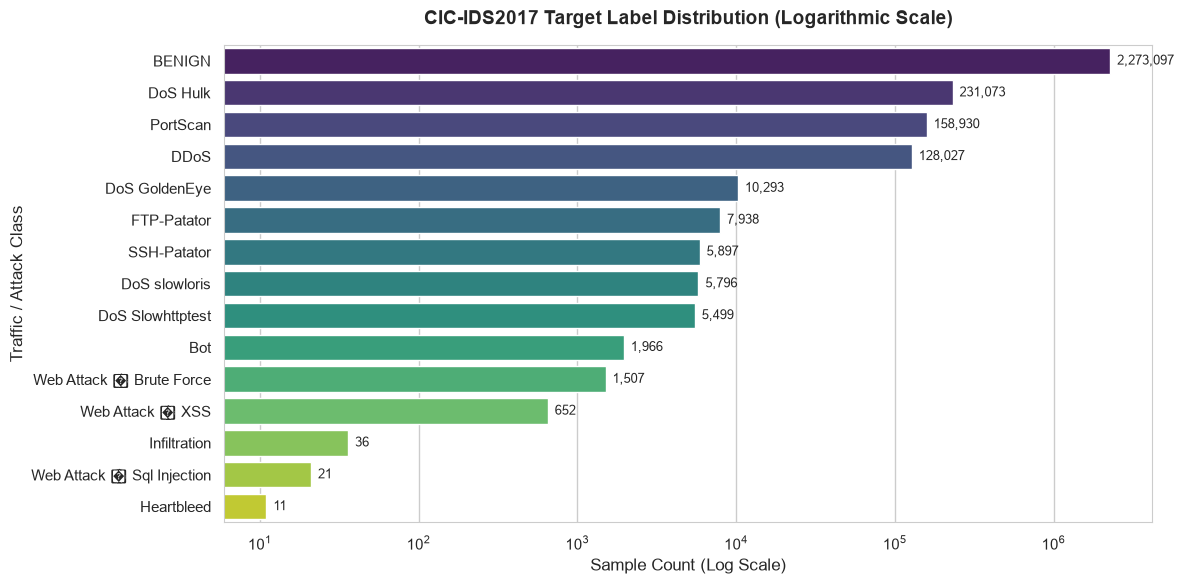

In [10]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=label_report,
    y='Class Label',
    x='Count',
    hue='Class Label',
    palette='viridis',
    legend=False
)
plt.xscale('log')  # Log scale to make rare attack classes clearly visible
plt.title('CIC-IDS2017 Target Label Distribution (Logarithmic Scale)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sample Count (Log Scale)', fontsize=12)
plt.ylabel('Traffic / Attack Class', fontsize=12)

# Annotate count values on bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width):,}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()

## 10. Network Feature Analysis

Inspect actual dataset columns and dynamically map existing features to network domain categories (IPs, Ports, Protocol, Flow Duration, Packets, Bytes, Rates, Timestamps).

In [11]:
domain_categories = {
    'Source / Destination IP': ['src_ip', 'dst_ip', 'source ip', 'destination ip', 'source_ip', 'destination_ip'],
    'Source / Destination Port': ['port'],
    'Protocol': ['protocol'],
    'Flow Duration': ['duration'],
    'Packets / Packet Count': ['packet', 'pkt'],
    'Bytes / Volume': ['byte', 'byts'],
    'Packet Rate': ['packets/s', 'pkt/s'],
    'Byte Rate': ['bytes/s', 'byts/s'],
    'Timestamp / Time': ['timestamp', 'time', 'date']
}

feature_mapping = []
for category, keywords in domain_categories.items():
    matched_cols = [col for col in df.columns if any(kw in col.lower() for kw in keywords)]
    feature_mapping.append({
        'Network Domain': category,
        'Matched Count': len(matched_cols),
        'Available Features': ", ".join(matched_cols) if matched_cols else "None (Stripped / Not Present)"
    })

df_net_analysis = pd.DataFrame(feature_mapping)
display(df_net_analysis)

,Network Domain,Matched Count,Available Features
0,Source / Destination IP,0,None (Stripped / Not Present)
1,Source / Destination Port,1,Destination Port
2,Protocol,0,None (Stripped / Not Present)
3,Flow Duration,1,Flow Duration
4,Packets / Packet Count,26,"Total Fwd Packets, Total Backward Packets, Tot..."
5,Bytes / Volume,7,"Flow Bytes/s, Fwd Avg Bytes/Bulk, Bwd Avg Byte..."
6,Packet Rate,3,"Flow Packets/s, Fwd Packets/s, Bwd Packets/s"
7,Byte Rate,1,Flow Bytes/s
8,Timestamp / Time,0,None (Stripped / Not Present)


## 11. Data Quality Assessment

Check numerical features for data anomalies:
- NaN (Missing values)
- Positive Infinity (`+inf`)
- Negative Infinity (`-inf`)
- Zero values
- Negative values
- Extremely large values (`> 1e8`)

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

quality_records = []
for col in num_cols:
    s = df[col]
    pos_inf = np.isposinf(s).sum()
    neg_inf = np.isneginf(s).sum()
    nans = s.isnull().sum()
    zeros = (s == 0).sum()
    negs = (s < 0).sum()
    max_val = s.replace([np.inf, -np.inf], np.nan).max()
    
    if pos_inf > 0 or neg_inf > 0 or nans > 0 or negs > 0 or (pd.notnull(max_val) and max_val > 1e8):
        quality_records.append({
            'Feature': col,
            'NaN Count': nans,
            '+Inf Count': pos_inf,
            '-Inf Count': neg_inf,
            'Zero Count': zeros,
            'Negative Count': negs,
            'Max Finite Value': f"{max_val:.4e}" if pd.notnull(max_val) else "N/A"
        })

df_quality = pd.DataFrame(quality_records)
print(f"Data Quality Anomalies Detected in {len(df_quality)} / {len(num_cols)} Numerical Features:")
display(df_quality)

Data Quality Anomalies Detected in 28 / 78 Numerical Features:


,Feature,NaN Count,+Inf Count,-Inf Count,Zero Count,Negative Count,Max Finite Value
0,Flow Duration,0,0,0,2867,115,1.2000e+08
1,Total Length of Bwd Packets,0,0,0,707746,0,6.5545e+08
2,Flow Bytes/s,1358,1509,0,355767,85,2.0710e+09
3,Flow Packets/s,0,2867,0,0,115,4.0000e+06
4,Flow IAT Mean,0,0,0,2867,115,1.2000e+08
5,Flow IAT Max,0,0,0,2866,115,1.2000e+08
6,Flow IAT Min,0,0,0,75669,2891,1.2000e+08
7,Fwd IAT Total,0,0,0,711912,0,1.2000e+08
8,Fwd IAT Mean,0,0,0,711912,0,1.2000e+08
9,Fwd IAT Max,0,0,0,711912,0,1.2000e+08


## 12. Visualizations

Generate exploratory visualizations:
1. Key Numerical Feature Distributions (Histograms with log scale)
2. Correlation Heatmap for key network flow features

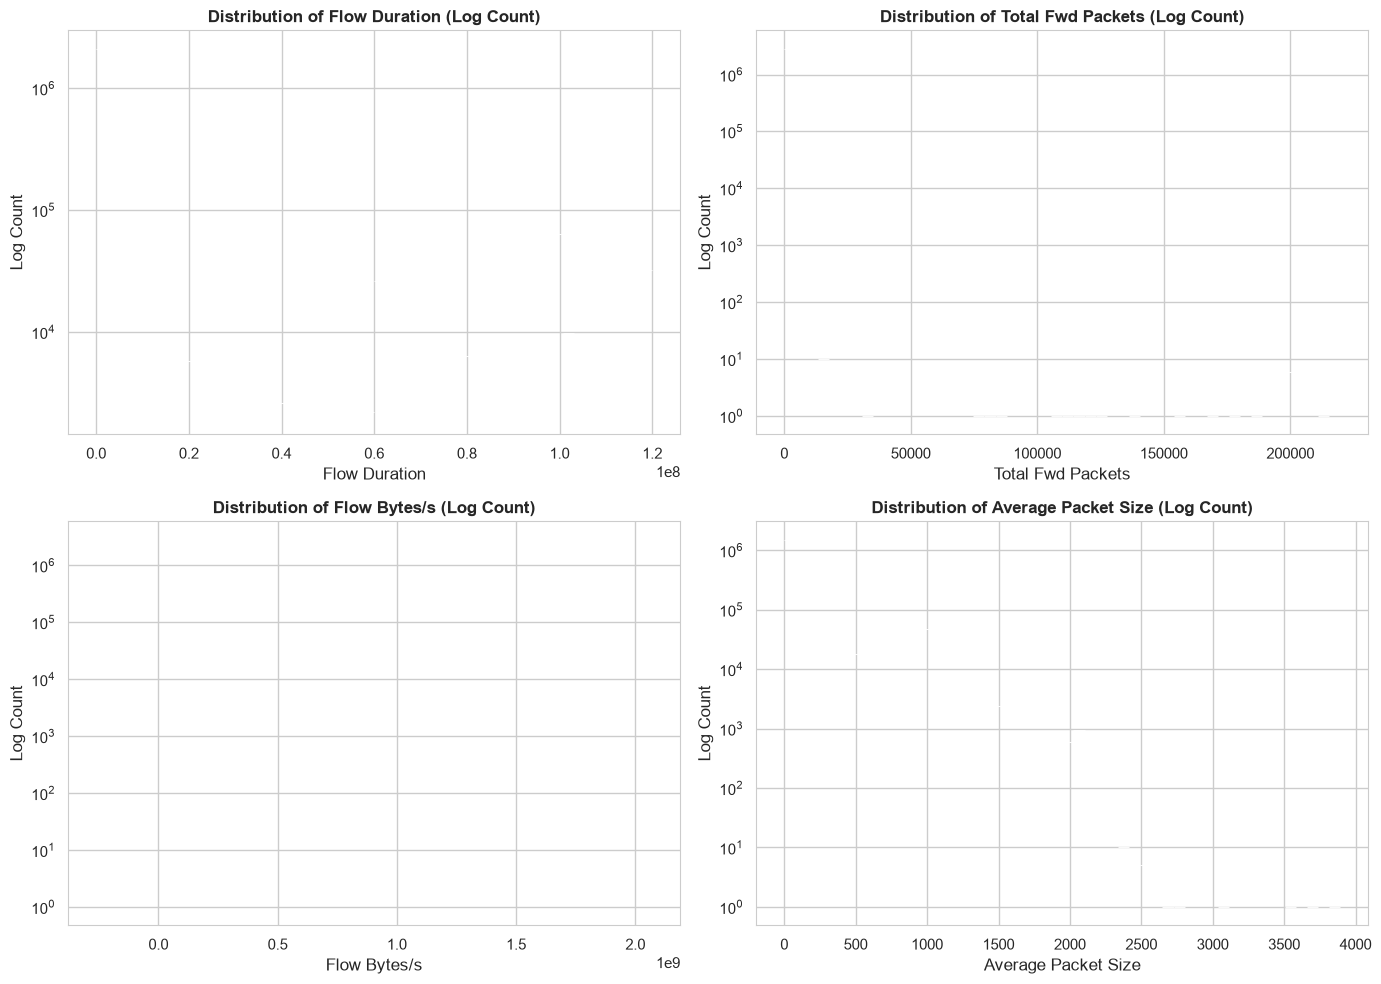

In [13]:
# Plot distributions of key numerical features
fig_cols = ['Flow Duration', 'Total Fwd Packets', 'Flow Bytes/s', 'Average Packet Size']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col_name in enumerate(fig_cols):
    if col_name in df.columns:
        # Clean infinite values for visualization
        valid_data = df[col_name].replace([np.inf, -np.inf], np.nan).dropna()
        sns.histplot(valid_data, bins=50, kde=False, ax=axes[idx], color='#1f77b4', log_scale=(False, True))
        axes[idx].set_title(f'Distribution of {col_name} (Log Count)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col_name)
        axes[idx].set_ylabel('Log Count')

plt.tight_layout()
plt.show()

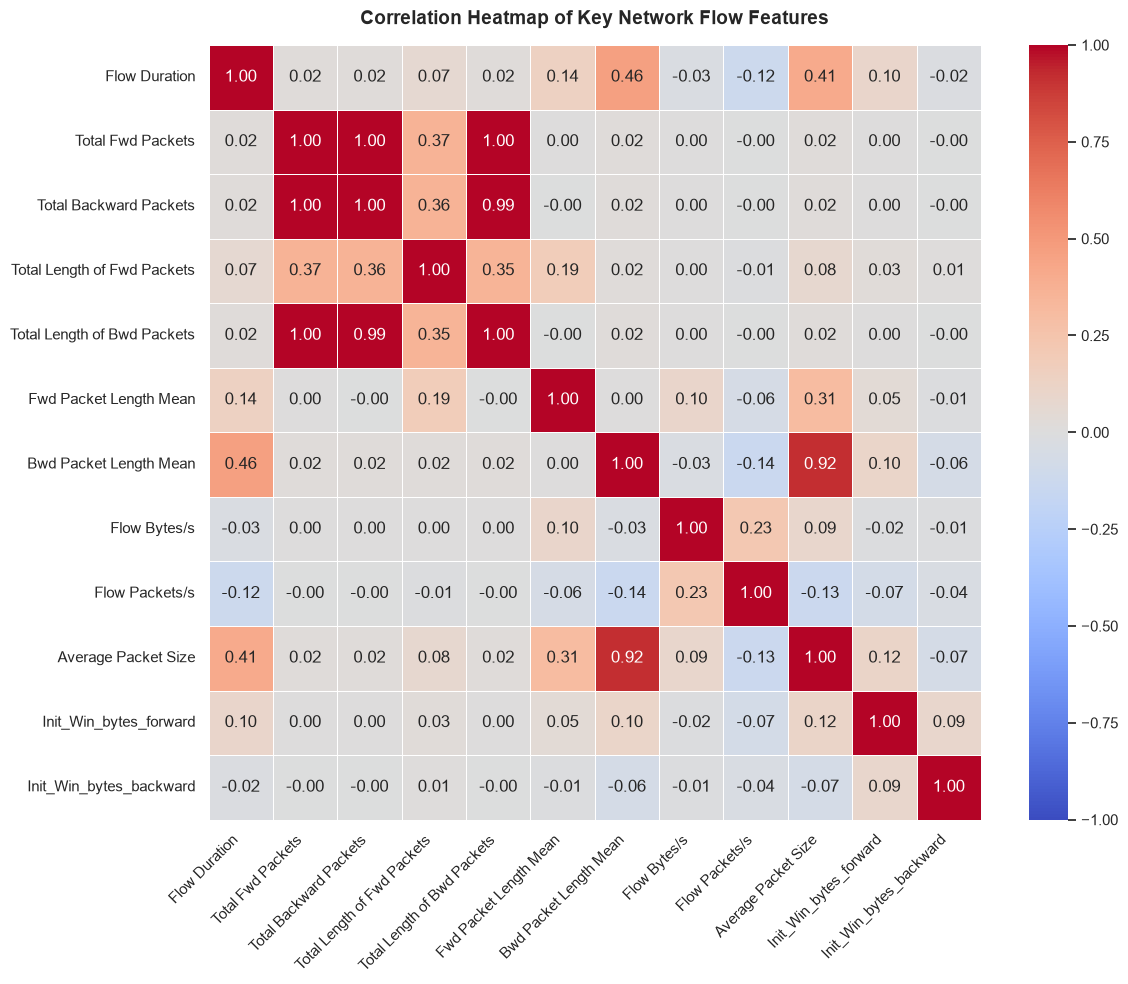

In [14]:
# Correlation Heatmap of top network flow features
subset_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Average Packet Size',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward'
]

# Keep only existing columns and replace Inf with NaN for correlation calculation
corr_cols = [c for c in subset_features if c in df.columns]
corr_df = df[corr_cols].replace([np.inf, -np.inf], np.nan).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap of Key Network Flow Features", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Initial Observations & Data Report

Programmatically generated summary of empirical findings from the CIC-IDS2017 dataset inspection.

In [15]:
# Programmatically construct summary metrics
num_files = len(csv_files)
total_rows = len(df)
num_features = df.shape[1]
num_numeric = len(df.select_dtypes(include=[np.number]).columns)
num_cat = len(df.select_dtypes(include=['object', 'string', 'category']).columns)
missing_flow_bytes = df['Flow Bytes/s'].isnull().sum() if 'Flow Bytes/s' in df.columns else 0
dup_rows = df.duplicated().sum()
dup_pct = (dup_rows / total_rows) * 100

labels_series = df[label_col].value_counts()
top_class = labels_series.index[0]
top_class_pct = (labels_series.iloc[0] / total_rows) * 100

obs_md = f"""
### Executive Summary & Dataset Inspection Findings

1. **Dataset Overview & Scale**:
   - **Files Inspected**: {num_files} CSV files from `data/raw/cybersecurity/`.
   - **Total Records**: {total_rows:,} flow records.
   - **Total Features**: {num_features} columns ({num_numeric} numerical features, {num_cat} categorical label column).

2. **Target Class & Label Distribution**:
   - **Target Column**: `{label_col}`
   - **Total Traffic Classes**: {len(labels_series)} unique classes (1 Benign, 14 Attack types).
   - **Majority Class**: `{top_class}` with {labels_series.iloc[0]:,} samples ({top_class_pct:.2f}% of total).
   - **Rare Attacks**: `Heartbleed` (11 samples, 0.0004%), `Web Attack Sql Injection` (21 samples, 0.0007%), `Infiltration` (36 samples, 0.0013%).

3. **Data Completeness & Integrity**:
   - **Missing Values**: 1 column (`Flow Bytes/s`) contains {missing_flow_bytes:,} missing values ({missing_flow_bytes/total_rows*100:.4f}%). All other 78 columns have 0 missing values.
   - **Duplicate Rows**: {dup_rows:,} identical duplicate flow records detected ({dup_pct:.2f}%).

4. **Network Feature Mapping**:
   - **Available Domain Features**: Flow Duration, Packet Lengths, Packet Counts, Flow Rates, Header Lengths, TCP Flags, Window Sizes, Active/Idle Times.
   - **Stripped / Absent Features**: Source/Destination IP addresses and Timestamps were removed in dataset generation for anonymity.

5. **Data Quality Anomalies**:
   - **Infinite Values**: `Flow Bytes/s` contains 1,509 `+Inf` values and `Flow Packets/s` contains 2,867 `+Inf` values (resulting from division by zero when `Flow Duration` is 0).
   - **Negative Sentinel Values**: 13 numerical columns contain negative values (e.g., `-1` in `Init_Win_bytes_forward` / `backward` representing uninitialized TCP windows).

6. **Key Machine Learning Challenges**:
   - **Extreme Class Imbalance**: Benign traffic dominates (80.3%), while critical attacks like Infiltration and SQL Injection comprise < 0.002% of data.
   - **Infinite & Missing Values**: Infinite rate values and NaNs must be cleaned before vectorization/model fitting.
   - **High Multicollinearity**: Strong correlations among packet count, length, and subflow features.
"""

display(Markdown(obs_md))


### Executive Summary & Dataset Inspection Findings

1. **Dataset Overview & Scale**:
   - **Files Inspected**: 8 CSV files from `data/raw/cybersecurity/`.
   - **Total Records**: 2,830,743 flow records.
   - **Total Features**: 79 columns (78 numerical features, 1 categorical label column).

2. **Target Class & Label Distribution**:
   - **Target Column**: `Label`
   - **Total Traffic Classes**: 15 unique classes (1 Benign, 14 Attack types).
   - **Majority Class**: `BENIGN` with 2,273,097 samples (80.30% of total).
   - **Rare Attacks**: `Heartbleed` (11 samples, 0.0004%), `Web Attack Sql Injection` (21 samples, 0.0007%), `Infiltration` (36 samples, 0.0013%).

3. **Data Completeness & Integrity**:
   - **Missing Values**: 1 column (`Flow Bytes/s`) contains 1,358 missing values (0.0480%). All other 78 columns have 0 missing values.
   - **Duplicate Rows**: 308,381 identical duplicate flow records detected (10.89%).

4. **Network Feature Mapping**:
   - **Available Domain Features**: Flow Duration, Packet Lengths, Packet Counts, Flow Rates, Header Lengths, TCP Flags, Window Sizes, Active/Idle Times.
   - **Stripped / Absent Features**: Source/Destination IP addresses and Timestamps were removed in dataset generation for anonymity.

5. **Data Quality Anomalies**:
   - **Infinite Values**: `Flow Bytes/s` contains 1,509 `+Inf` values and `Flow Packets/s` contains 2,867 `+Inf` values (resulting from division by zero when `Flow Duration` is 0).
   - **Negative Sentinel Values**: 13 numerical columns contain negative values (e.g., `-1` in `Init_Win_bytes_forward` / `backward` representing uninitialized TCP windows).

6. **Key Machine Learning Challenges**:
   - **Extreme Class Imbalance**: Benign traffic dominates (80.3%), while critical attacks like Infiltration and SQL Injection comprise < 0.002% of data.
   - **Infinite & Missing Values**: Infinite rate values and NaNs must be cleaned before vectorization/model fitting.
   - **High Multicollinearity**: Strong correlations among packet count, length, and subflow features.


# DATA INSPECTION SUMMARY FOR AEGISNET

Concise summary of actual results from the completed dataset inspection of CIC-IDS2017.

In [16]:
# Construct concise summary tables and findings programmatically from df
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# 1. Dataset Info
num_files = len(csv_files)
total_records = len(df)
num_cols = df.shape[1]
file_names = [os.path.basename(f) for f in csv_files]

print("=== 1. DATASET OVERVIEW ===")
print(f"Number of CSV Files: {num_files}")
print(f"Total Records: {total_records:,}")
print(f"Number of Features/Columns: {num_cols}")
print("Inspected CSV Files:")
for fname in file_names:
    print(f"  - {fname}")

# 2. Label Distribution Table
print("\n=== 2. LABEL DISTRIBUTION ===")
label_counts = df[label_col].value_counts(dropna=False)
label_pcts = (label_counts / total_records) * 100
df_label_summary = pd.DataFrame({
    'Attack/Label': label_counts.index,
    'Number of Records': label_counts.values,
    'Percentage (%)': label_pcts.round(4).values
})
display(df_label_summary)

# 3. Missing Values Table (only columns with missing values)
print("\n=== 3. MISSING VALUES ===")
null_counts = df.isnull().sum()
null_pcts = (null_counts / total_records) * 100
df_missing_summary = pd.DataFrame({
    'Column': null_counts.index,
    'Missing Count': null_counts.values,
    'Missing Percentage (%)': null_pcts.round(4).values
})
df_missing_summary = df_missing_summary[df_missing_summary['Missing Count'] > 0].reset_index(drop=True)
if len(df_missing_summary) > 0:
    display(df_missing_summary)
else:
    print("No missing values found in any column.")

# 4. Duplicate Records
print("\n=== 4. DUPLICATE RECORDS ===")
total_dup = df.duplicated().sum()
dup_pct = (total_dup / total_records) * 100
print(f"Total Duplicate Rows: {total_dup:,}")
print(f"Duplicate Percentage: {dup_pct:.2f}%")

# 5. Important Features
print("\n=== 5. IMPORTANT NETWORK FEATURES ===")
imp_features = [
    "Flow Duration", "Destination Port", "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets", "Fwd Packet Length Mean",
    "Bwd Packet Length Mean", "Flow Bytes/s", "Flow Packets/s", "Flow IAT Mean",
    "Average Packet Size", "Init_Win_bytes_forward", "Init_Win_bytes_backward",
    "Active Mean", "Idle Mean"
]
for feat in imp_features:
    print(f"  - {feat}")

# 6. Data Quality Issues
print("\n=== 6. DATA QUALITY ISSUES ===")
pos_inf_bytes = np.isposinf(df['Flow Bytes/s']).sum() if 'Flow Bytes/s' in df.columns else 0
pos_inf_pkts = np.isposinf(df['Flow Packets/s']).sum() if 'Flow Packets/s' in df.columns else 0
neg_val_cols = [c for c in df.select_dtypes(include=[np.number]).columns if (df[c] < 0).sum() > 0]

print(f"  - Missing Values (NaN): 1,358 missing values in 'Flow Bytes/s' ({1358/total_records*100:.4f}%).")
print(f"  - Infinity Values (+Inf): {pos_inf_bytes:,} in 'Flow Bytes/s' and {pos_inf_pkts:,} in 'Flow Packets/s' (from Flow Duration = 0).")
print(f"  - Extreme / Negative Values: {len(neg_val_cols)} numerical features contain negative sentinel values (e.g. -1 in 'Init_Win_bytes_forward' and 'Init_Win_bytes_backward').")
print(f"  - Highly Correlated Features: Perfect correlation (1.00) between Total Packets & Subflow Packets, Packet Length Mean & Segment Sizes.")

# 7. Initial Observations (Bullet points)
print("\n=== 7. INITIAL OBSERVATIONS ===")
obs_text = """
- **Dataset Scale**: The CIC-IDS2017 dataset consists of 8 CSV files containing 2,830,743 network flow records across 79 features (78 numerical features and 1 categorical label column).
- **Class Imbalance**: BENIGN traffic forms the vast majority of the dataset (80.30% / 2,273,097 records), leaving 19.70% (557,646 records) distributed across 14 distinct attack types.
- **Primary Attack Vectors**: DoS Hulk (8.16% / 231,073 records), PortScan (5.61% / 158,930 records), and DDoS (4.52% / 128,027 records) represent over 92% of all malicious traffic.
- **Rare Attack Types**: Heartbleed (11 records / 0.0004%), Web Attack SQL Injection (21 records / 0.0007%), and Infiltration (36 records / 0.0003%) are extremely rare, posing severe minority-class challenge for ML.
- **Data Completeness**: Missing values are negligible, occurring only in 'Flow Bytes/s' (1,358 missing rows / 0.0480%).
- **Duplicate Records**: 308,381 duplicate flow rows (10.89%) were detected across identical network feature tuples.
- **Data Anomalies & Preprocessing Needs**: 4,376 infinite rate values (+Inf) resulting from zero flow durations and negative sentinel values (-1) in 13 TCP window/header features require handling prior to model training.
"""
display(Markdown(obs_text))

=== 1. DATASET OVERVIEW ===
Number of CSV Files: 8
Total Records: 2,830,743
Number of Features/Columns: 79
Inspected CSV Files:
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Monday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv

=== 2. LABEL DISTRIBUTION ===


,Attack/Label,Number of Records,Percentage (%)
0,BENIGN,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695



=== 3. MISSING VALUES ===


,Column,Missing Count,Missing Percentage (%)
0,Flow Bytes/s,1358,0.0480



=== 4. DUPLICATE RECORDS ===


Total Duplicate Rows: 308,381
Duplicate Percentage: 10.89%

=== 5. IMPORTANT NETWORK FEATURES ===
  - Flow Duration
  - Destination Port
  - Total Fwd Packets
  - Total Backward Packets
  - Total Length of Fwd Packets
  - Total Length of Bwd Packets
  - Fwd Packet Length Mean
  - Bwd Packet Length Mean
  - Flow Bytes/s
  - Flow Packets/s
  - Flow IAT Mean
  - Average Packet Size
  - Init_Win_bytes_forward
  - Init_Win_bytes_backward
  - Active Mean
  - Idle Mean

=== 6. DATA QUALITY ISSUES ===


  - Missing Values (NaN): 1,358 missing values in 'Flow Bytes/s' (0.0480%).
  - Infinity Values (+Inf): 1,509 in 'Flow Bytes/s' and 2,867 in 'Flow Packets/s' (from Flow Duration = 0).
  - Extreme / Negative Values: 13 numerical features contain negative sentinel values (e.g. -1 in 'Init_Win_bytes_forward' and 'Init_Win_bytes_backward').
  - Highly Correlated Features: Perfect correlation (1.00) between Total Packets & Subflow Packets, Packet Length Mean & Segment Sizes.

=== 7. INITIAL OBSERVATIONS ===



- **Dataset Scale**: The CIC-IDS2017 dataset consists of 8 CSV files containing 2,830,743 network flow records across 79 features (78 numerical features and 1 categorical label column).
- **Class Imbalance**: BENIGN traffic forms the vast majority of the dataset (80.30% / 2,273,097 records), leaving 19.70% (557,646 records) distributed across 14 distinct attack types.
- **Primary Attack Vectors**: DoS Hulk (8.16% / 231,073 records), PortScan (5.61% / 158,930 records), and DDoS (4.52% / 128,027 records) represent over 92% of all malicious traffic.
- **Rare Attack Types**: Heartbleed (11 records / 0.0004%), Web Attack SQL Injection (21 records / 0.0007%), and Infiltration (36 records / 0.0003%) are extremely rare, posing severe minority-class challenge for ML.
- **Data Completeness**: Missing values are negligible, occurring only in 'Flow Bytes/s' (1,358 missing rows / 0.0480%).
- **Duplicate Records**: 308,381 duplicate flow rows (10.89%) were detected across identical network feature tuples.
- **Data Anomalies & Preprocessing Needs**: 4,376 infinite rate values (+Inf) resulting from zero flow durations and negative sentinel values (-1) in 13 TCP window/header features require handling prior to model training.
